# COVID-19 Global Pandemic — Feature Engineering & Analytical Modeling

**Role:** Feature Engineering & Analytical Modeling  
**Input:** `data/owid_covid_cleaned.csv` (output from the data cleaning pipeline)  

---

| Output file | Description |
|---|---|
| `data/processed/final_dataset.csv` | Full enriched dataset with all engineered features |
| `data/processed/country_summary.csv` | Latest-snapshot summary per country |
| `data/processed/continent_summary.csv` | Continent-level aggregated KPIs |
| `data/processed/global_summary.csv` | Global daily aggregates for time-series charts |

---

> **Notebook flow:** Sections 1–3 load and prepare the cleaned dataset. Section 4 drops pre-computed KPI columns that will be recalculated from scratch. Section 5 extracts date components. Section 6 recalculates all KPIs with full reproducibility. Sections 7–9 add rolling averages, aggregate the data at multiple geographic levels, and export the final files.


## Abstract

This notebook takes the cleaned OWID COVID-19 dataset and produces a fully enriched, analysis-ready version through three stages of transformation.

First, five pre-computed KPI columns (`cases_per_million`, `deaths_per_million`, `vaccination_rate_pct`, `case_fatality_rate`, `testing_rate`) are dropped. These columns exist in the cleaned dataset but were computed from the raw data before imputation. Recalculating them after imputation produces more complete and internally consistent values.

Second, the `date` column is decomposed into separate `year`, `month`, and `day` integer columns, and a continuous numeric representation (`date_normalized`) is derived using 2024-08-10 as the reference maximum — scaling all dates to a [0, 1] range suitable for modeling.

Third, all five KPIs are recalculated from the post-imputation data, 7-day rolling averages are computed per country, and three aggregation tables (country, continent, global) are produced for downstream visualization and analysis.


## 1. Setup & Data Loading

All path configuration is centralized in the first code cell. Update `INPUT_PATH` and `OUTPUT_DIR` to match your local environment or cloud storage location before running the notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ── Path configuration ────────────────────────────────────────────────────────
# Update these paths to match your local or cloud storage layout.
# If using Google Colab with Drive, mount Drive first and set paths accordingly.

INPUT_PATH = r'F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed\owid_covid_cleaned.csv'
OUTPUT_DIR = r'F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load cleaned dataset ──────────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Date range  : {df['date'].min().date()}  ->  {df['date'].max().date()}")
print(f"  Countries   : {df['location'].nunique()}")
print(f"  Continents  : {df['continent'].nunique()}")


Dataset loaded: 395,311 rows x 66 columns
  Date range  : 2020-01-01  ->  2024-08-14
  Countries   : 237
  Continents  : 6


## 2. Exploratory Missing Value Analysis

Before applying any imputation, this section documents the extent and distribution of missing values across all columns. The strategy applied to each column in Section 3 follows directly from this assessment.

Columns are grouped into three bands based on missing rate: above 80% (too sparse for imputation), 30–80% (selective imputation where meaningful), and below 30% (standard imputation).


In [3]:
# Missing value summary — sorted by rate descending
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(1)
dtype_series  = df.dtypes.astype(str)

missing_df = pd.DataFrame({
    'Column'        : missing_count.index,
    'Missing Count' : missing_count.values,
    'Missing %'     : missing_pct.values,
    'Dtype'         : dtype_series.values
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)} of {df.shape[1]}")
print()
print(missing_df.to_string(index=False))


Columns with missing values: 48 of 66

                                    Column  Missing Count  Missing %   Dtype
   excess_mortality_cumulative_per_million         381948      96.60 float64
                          excess_mortality         381948      96.60 float64
               excess_mortality_cumulative         381948      96.60 float64
      excess_mortality_cumulative_absolute         381948      96.60 float64
         weekly_icu_admissions_per_million         372963      94.30 float64
                     weekly_icu_admissions         372963      94.30 float64
        weekly_hosp_admissions_per_million         362045      91.60 float64
                    weekly_hosp_admissions         362045      91.60 float64
                 hosp_patients_per_million         356640      90.20 float64
                             hosp_patients         356640      90.20 float64
                  icu_patients_per_million         356017      90.10 float64
                              icu_pat

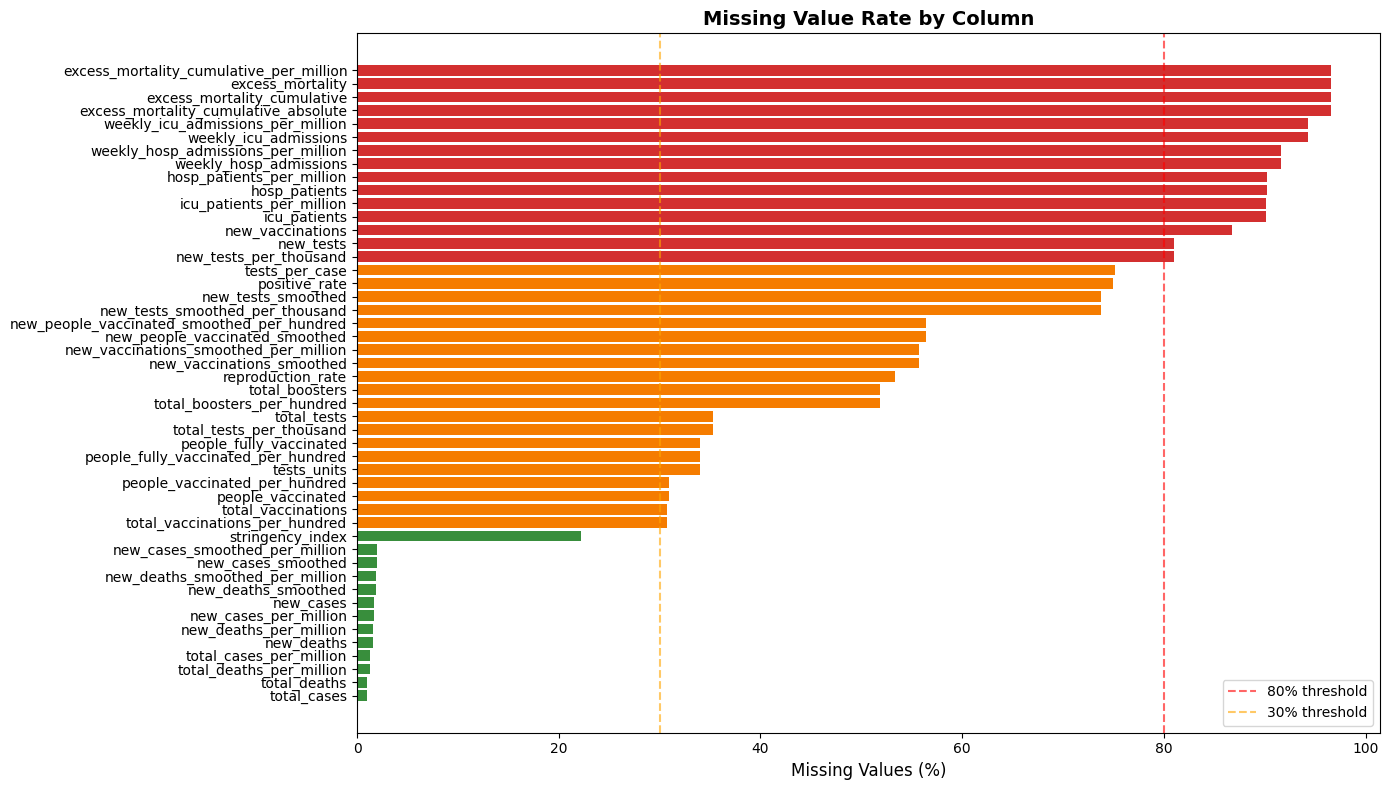

Chart saved -> data/processed/missing_values_overview.png


In [4]:
# Horizontal bar chart of missing value rates
fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    '#d32f2f' if p > 80 else
    '#f57c00' if p > 30 else
    '#388e3c'
    for p in missing_df['Missing %']
]

ax.barh(missing_df['Column'], missing_df['Missing %'], color=colors)
ax.axvline(x=80, color='red',    linestyle='--', alpha=0.6, label='80% threshold')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.6, label='30% threshold')
ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Missing Value Rate by Column', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/missing_values_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved -> data/processed/missing_values_overview.png")


### Missing Value Strategy — Column by Column

| Column group | Missing % | Strategy | Reasoning |
|---|---|---|---|
| `total_cases`, `total_deaths` | ~1% | Forward fill per country | Cumulative — value on unreported days equals the previous reported total |
| `new_cases`, `new_deaths` | ~1.7% | Fill 0 | No report on a given day is functionally equivalent to zero new events |
| `new_cases_smoothed`, `new_deaths_smoothed` | ~2% | Fill 0 | Derived from daily new values; zero is the correct carry-forward |
| `*_per_million` (cases / deaths) | ~1–2% | Fill 0 | Derived from the above; consistent treatment |
| `reproduction_rate` | 53% | Keep NaN | No reliable substitute; used only where available |
| `icu_patients`, `hosp_patients`, `weekly_*` | 90–94% | Keep NaN | Reported by very few countries; imputation would manufacture data |
| `total_tests`, `total_tests_per_thousand` | 35% | Forward fill per country | Cumulative; gaps reflect missing reporting days, not absent testing |
| `new_tests`, `positive_rate`, `tests_per_case` | 73–81% | Fill 0 / Keep NaN | Available only where testing programs were established |
| `tests_units` | 34% | Fill 'Unknown' | Categorical; unknown is a valid and informative state |
| `total_vaccinations`, `people_vaccinated`, `people_fully_vaccinated` | 30–34% | Forward fill per country | Cumulative; vaccination programs started mid-pandemic |
| `total_boosters`, `new_vaccinations_smoothed` | 51–56% | Forward fill then fill 0 | Boosters rolled out later; pre-rollout rows are legitimately zero |
| `stringency_index` | 22% | Forward fill per country | Policy responses change slowly; carry-forward is appropriate |
| `case_fatality_rate` | 8.3% | **Recalculate in Section 6** | Dropped and recomputed from post-imputation data |
| `excess_mortality_*` | 96.6% | Keep NaN | Only ~4% of rows have this data; available for countries with civil registration systems |
| Static columns (GDP, age, density, etc.) | 0% | No action | Fully handled in the data cleaning pipeline |


## 3. Missing Value Imputation

Imputation is applied in the order described in Section 2. The DataFrame is sorted by country and date before any fill operation to ensure that forward-fill propagates values in the correct temporal direction.


In [5]:
# Sort chronologically within each country — required for ffill to be meaningful
df = df.sort_values(['location', 'date']).reset_index(drop=True)
print("Data sorted by [location, date].")


Data sorted by [location, date].


In [6]:
# 3.1  Cumulative columns — Forward fill per country
# Gaps in cumulative columns represent unreported days, not reductions in the count.
cumulative_cols = [
    'total_cases', 'total_deaths',
    'total_cases_per_million', 'total_deaths_per_million',
    'total_tests', 'total_tests_per_thousand',
    'total_vaccinations', 'total_vaccinations_per_hundred',
    'people_vaccinated', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated', 'people_fully_vaccinated_per_hundred',
    'total_boosters', 'total_boosters_per_hundred',
]

df[cumulative_cols] = (
    df.groupby('location')[cumulative_cols]
      .transform(lambda g: g.ffill())
)
# Countries with no data at all remain 0 rather than NaN
df[cumulative_cols] = df[cumulative_cols].fillna(0)

print(f"Forward-filled {len(cumulative_cols)} cumulative columns.")


Forward-filled 14 cumulative columns.


In [7]:
# 3.2  Daily new value columns — Fill 0
# A missing new_cases or new_deaths entry means no report was submitted that day.
# The absence of a report is treated as zero new events.
daily_zero_cols = [
    'new_cases', 'new_deaths',
    'new_cases_smoothed', 'new_deaths_smoothed',
    'new_cases_per_million', 'new_deaths_per_million',
    'new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million',
    'new_tests', 'new_tests_per_thousand',
    'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
    'new_vaccinations',
    'new_vaccinations_smoothed', 'new_vaccinations_smoothed_per_million',
    'new_people_vaccinated_smoothed', 'new_people_vaccinated_smoothed_per_hundred',
]

df[daily_zero_cols] = df[daily_zero_cols].fillna(0)
print(f"Filled {len(daily_zero_cols)} daily columns with 0.")


Filled 17 daily columns with 0.


In [8]:
# 3.3  Stringency index — Forward fill per country
# Government policies change infrequently. Carrying the last known value forward
# correctly represents that policies remain in effect until explicitly changed.
df['stringency_index'] = (
    df.groupby('location')['stringency_index']
      .transform(lambda g: g.ffill().bfill())
)
df['stringency_index'] = df['stringency_index'].fillna(0)
print("stringency_index: forward-filled per country.")


stringency_index: forward-filled per country.


In [9]:
# 3.4  Booster columns — Forward fill then fill 0
# Pre-rollout rows (before late 2020) are legitimately zero.
booster_cols = ['total_boosters', 'total_boosters_per_hundred']
df[booster_cols] = (
    df.groupby('location')[booster_cols]
      .transform(lambda g: g.ffill())
      .fillna(0)
)
print("Booster columns: forward-filled per country; remaining -> 0.")


Booster columns: forward-filled per country; remaining -> 0.


In [10]:
# 3.5  tests_units — Fill 'Unknown'
# 'Unknown' is an informative category: the country reported testing data
# but did not specify the counting convention used.
df['tests_units'] = df['tests_units'].fillna('Unknown')
print("tests_units: NaN -> 'Unknown'.")


tests_units: NaN -> 'Unknown'.


In [11]:
# 3.6  Imputation validation
# Confirm that all targeted columns are fully filled.
imputed_cols = cumulative_cols + daily_zero_cols + booster_cols + ['stringency_index', 'tests_units']
remaining = df[imputed_cols].isnull().sum()
still_missing = remaining[remaining > 0]

if still_missing.empty:
    print("All targeted columns fully imputed — 0 missing values remain.")
else:
    print("Missing values remain in some targeted columns:")
    print(still_missing)


All targeted columns fully imputed — 0 missing values remain.


In [12]:
# Columns intentionally kept as NaN — too sparse or no valid substitute
kept_nan_cols = [
    'reproduction_rate',
    'icu_patients', 'icu_patients_per_million',
    'hosp_patients', 'hosp_patients_per_million',
    'weekly_icu_admissions', 'weekly_icu_admissions_per_million',
    'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million',
    'positive_rate', 'tests_per_case',
    'excess_mortality_cumulative_absolute',
    'excess_mortality_cumulative',
    'excess_mortality',
    'excess_mortality_cumulative_per_million',
]

print("Columns intentionally kept as NaN (sparse or no logical substitute):")
for col in kept_nan_cols:
    pct = df[col].isnull().mean() * 100
    print(f"  {col:<50}  {pct:.1f}% missing")


Columns intentionally kept as NaN (sparse or no logical substitute):
  reproduction_rate                                   53.3% missing
  icu_patients                                        90.1% missing
  icu_patients_per_million                            90.1% missing
  hosp_patients                                       90.2% missing
  hosp_patients_per_million                           90.2% missing
  weekly_icu_admissions                               94.3% missing
  weekly_icu_admissions_per_million                   94.3% missing
  weekly_hosp_admissions                              91.6% missing
  weekly_hosp_admissions_per_million                  91.6% missing
  positive_rate                                       75.0% missing
  tests_per_case                                      75.2% missing
  excess_mortality_cumulative_absolute                96.6% missing
  excess_mortality_cumulative                         96.6% missing
  excess_mortality                             

## 4. Drop Pre-Computed KPI Columns

Five KPI columns present in the cleaned dataset were originally computed from the raw, pre-imputation data:

| Column | Formula |
|---|---|
| `cases_per_million` | `total_cases / population * 1,000,000` |
| `deaths_per_million` | `total_deaths / population * 1,000,000` |
| `vaccination_rate_pct` | `people_fully_vaccinated / population * 100` |
| `case_fatality_rate` | `total_deaths / total_cases * 100` |
| `testing_rate` | `total_tests / population * 1,000` |

These columns are dropped here and recalculated from scratch in Section 6 using the post-imputation values of `total_cases`, `total_deaths`, `total_tests`, `people_fully_vaccinated`, and `population`. Recalculating after imputation produces more complete values — rows that were previously null due to missing inputs will now yield a valid KPI figure.


In [13]:
# Drop the five pre-computed KPI columns
kpi_cols_to_drop = [
    'cases_per_million',
    'deaths_per_million',
    'vaccination_rate_pct',
    'case_fatality_rate',
    'testing_rate',
]

# Only drop columns that actually exist (guards against running the cell twice)
cols_present = [c for c in kpi_cols_to_drop if c in df.columns]
df.drop(columns=cols_present, inplace=True)

print(f"Dropped {len(cols_present)} pre-computed KPI columns: {cols_present}")
print(f"Dataset shape after drop: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dropped 0 pre-computed KPI columns: []
Dataset shape after drop: 395,311 rows x 66 columns


## 5. Date Feature Extraction

The `date` column is a datetime object. This section derives four additional columns from it:

| New column | Type | Description |
|---|---|---|
| `year` | integer | Calendar year extracted from `date` |
| `month` | integer | Calendar month (1–12) extracted from `date` |
| `day` | integer | Day of month (1–31) extracted from `date` |
| `date_normalized` | float [0, 1] | Min-max normalized date, where 0 = earliest observation and 1 = 2024-08-10 (the reference maximum) |

The `date_normalized` column maps each date to a continuous numeric value in [0, 1]. The reference maximum is fixed at 2024-08-10 rather than derived from the data's actual maximum, so the normalization scale is stable and reproducible across different dataset versions. Any date beyond the reference will produce a value greater than 1, which is expected and informative.

This feature is particularly useful in regression and time-series modeling contexts where a monotonically increasing numeric representation of time is needed without the arbitrary magnitude of raw ordinal day numbers.


In [14]:
# 5.1  Extract year, month, day as integer columns
df['year']  = df['date'].dt.year.astype(int)
df['month'] = df['date'].dt.month.astype(int)
df['day']   = df['date'].dt.day.astype(int)

print("Date components extracted:")
print(f"  year  : {df['year'].min()}  ->  {df['year'].max()}")
print(f"  month : {df['month'].min()}  ->  {df['month'].max()}")
print(f"  day   : {df['day'].min()}  ->  {df['day'].max()}")


Date components extracted:
  year  : 2020  ->  2024
  month : 1  ->  12
  day   : 1  ->  31


In [15]:
# 5.2  Normalized date — min-max scaled to [0, 1] using 2024-08-10 as the reference maximum
REFERENCE_DATE = pd.Timestamp('2024-08-10')
min_date       = df['date'].min()

# Number of days from the earliest observation to each row's date
days_elapsed   = (df['date'] - min_date).dt.days

# Number of days from the earliest observation to the reference maximum
scale          = (REFERENCE_DATE - min_date).days

df['date_normalized'] = (days_elapsed / scale).round(6)

print(f"date_normalized derived using reference date: {REFERENCE_DATE.date()}")
print(f"  Earliest date in dataset : {min_date.date()}  ->  date_normalized = 0.0")
print(f"  Reference date           : {REFERENCE_DATE.date()}  ->  date_normalized = 1.0")
print()
print(df[['date', 'year', 'month', 'day', 'date_normalized']].head(5).to_string(index=False))


date_normalized derived using reference date: 2024-08-10
  Earliest date in dataset : 2020-01-01  ->  date_normalized = 0.0
  Reference date           : 2024-08-10  ->  date_normalized = 1.0

      date  year  month  day  date_normalized
2020-01-05  2020      1    5             0.00
2020-01-06  2020      1    6             0.00
2020-01-07  2020      1    7             0.00
2020-01-08  2020      1    8             0.00
2020-01-09  2020      1    9             0.00


In [16]:
# 5.3  Verify the four new date columns
date_check = df[['date', 'year', 'month', 'day', 'date_normalized']].describe(include='all')
print("Date feature summary:")
print(date_check.T.to_string())


Date feature summary:
                    count                           mean                  min                  25%                  50%                  75%                  max  std
date               395311  2022-04-20 00:08:07.393470464  2020-01-01 00:00:00  2021-02-28 00:00:00  2022-04-19 00:00:00  2023-06-11 00:00:00  2024-08-14 00:00:00  NaN
year            395311.00                        2021.83              2020.00              2021.00              2022.00              2023.00              2024.00 1.33
month           395311.00                           6.22                 1.00                 3.00                 6.00                 9.00                12.00 3.40
day             395311.00                          15.73                 1.00                 8.00                16.00                23.00                31.00 8.80
date_normalized 395311.00                           0.50                 0.00                 0.25                 0.50                 0.75   

## 6. Feature Engineering — KPI Recalculation

The five KPI columns dropped in Section 4 are recalculated here from the post-imputation values of their input columns. This produces values for rows that were previously null due to missing inputs, and ensures all KPIs are internally consistent with the imputed base data.

| KPI | Formula | Units |
|---|---|---|
| `cases_per_million` | `total_cases / population * 1,000,000` | Cases per million population |
| `deaths_per_million` | `total_deaths / population * 1,000,000` | Deaths per million population |
| `vaccination_rate_pct` | `people_fully_vaccinated / population * 100` | % of population fully vaccinated |
| `case_fatality_rate` | `total_deaths / total_cases * 100` | % of confirmed cases resulting in death |
| `testing_rate` | `total_tests / population * 1,000` | Tests administered per 1,000 people |

Population is used as the denominator for three of the five KPIs. Rows where `population` is zero or null produce `NaN` rather than a division error. `vaccination_rate_pct` is capped at 100% because some countries report values above 100 when booster doses are counted as additional full-dose events.


In [17]:
# 6.1  Cases per million
df['cases_per_million'] = np.where(
    df['population'] > 0,
    (df['total_cases'] / df['population']) * 1_000_000,
    np.nan
).round(2)

print("cases_per_million  ->  total_cases / population x 1,000,000")
print(f"  Non-null: {df['cases_per_million'].notna().sum():,} rows")


cases_per_million  ->  total_cases / population x 1,000,000
  Non-null: 395,311 rows


In [18]:
# 6.2  Deaths per million
df['deaths_per_million'] = np.where(
    df['population'] > 0,
    (df['total_deaths'] / df['population']) * 1_000_000,
    np.nan
).round(2)

print("deaths_per_million ->  total_deaths / population x 1,000,000")
print(f"  Non-null: {df['deaths_per_million'].notna().sum():,} rows")


deaths_per_million ->  total_deaths / population x 1,000,000
  Non-null: 395,311 rows


In [19]:
# 6.3  Vaccination rate (% of population fully vaccinated)
df['vaccination_rate_pct'] = np.where(
    df['population'] > 0,
    (df['people_fully_vaccinated'] / df['population']) * 100,
    np.nan
).round(2)

# Cap at 100% — values above 100 arise when booster doses are counted as full-dose events
df['vaccination_rate_pct'] = df['vaccination_rate_pct'].clip(upper=100)

print("vaccination_rate_pct  ->  (people_fully_vaccinated / population) x 100  [capped at 100]")
print(f"  Range: {df['vaccination_rate_pct'].min():.1f}%  -  {df['vaccination_rate_pct'].max():.1f}%")


vaccination_rate_pct  ->  (people_fully_vaccinated / population) x 100  [capped at 100]
  Range: 0.0%  -  100.0%


In [20]:
# 6.4  Case fatality rate
# Defined only for rows where at least one confirmed case exists.
# Rows with total_cases = 0 produce NaN rather than a zero or infinity.
df['case_fatality_rate'] = np.where(
    df['total_cases'] > 0,
    (df['total_deaths'] / df['total_cases']) * 100,
    np.nan
).round(3)

print("case_fatality_rate  ->  (total_deaths / total_cases) x 100")
print(f"  Global mean CFR : {df['case_fatality_rate'].mean():.2f}%")


case_fatality_rate  ->  (total_deaths / total_cases) x 100
  Global mean CFR : 11.38%


In [21]:
# 6.5  Testing rate (tests per 1,000 people)
df['testing_rate'] = np.where(
    df['population'] > 0,
    (df['total_tests'] / df['population']) * 1_000,
    np.nan
).round(2)

print("testing_rate  ->  (total_tests / population) x 1,000")
print(f"  Maximum testing rate: {df['testing_rate'].max():.0f} tests per 1,000 people")


testing_rate  ->  (total_tests / population) x 1,000
  Maximum testing rate: 32926 tests per 1,000 people


In [22]:
# 6.6  Feature engineering summary
engineered_features = [
    'cases_per_million', 'deaths_per_million', 'vaccination_rate_pct',
    'case_fatality_rate', 'testing_rate',
    'year', 'month', 'day', 'date_normalized'
]

print("=" * 65)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 65)
summary = df[engineered_features].describe().T[['count', 'mean', 'min', 'max']]
summary['non-null %'] = (df[engineered_features].notnull().mean() * 100).round(1)
print(summary.to_string())


FEATURE ENGINEERING SUMMARY
                         count      mean     min       max  non-null %
cases_per_million    395311.00 111539.87    0.00 777237.23      100.00
deaths_per_million   395311.00    812.75    0.00   6489.80      100.00
vaccination_rate_pct 395311.00     31.97    0.00    100.00      100.00
case_fatality_rate   362487.00     11.38    0.00 103875.00       91.70
testing_rate         395311.00    911.83    0.00  32925.83      100.00
year                 395311.00   2021.83 2020.00   2024.00      100.00
month                395311.00      6.22    1.00     12.00      100.00
day                  395311.00     15.73    1.00     31.00      100.00
date_normalized      395311.00      0.50    0.00      1.00      100.00


## 7. Time-Series Enhancements — Rolling Averages

Daily case and death counts are noisy due to systematic reporting cycles: many countries report fewer cases on weekends and compensate with inflated counts at the start of the following week. A 7-day rolling average removes this weekly periodicity and reveals the underlying epidemic trend more clearly.

Rolling averages are computed per country using a minimum of 1 period at the start of the series, so early rows are not excluded entirely. The result is a smoothed daily value that can be compared across countries without the distortion of reporting cadence differences.


In [23]:
# 7.1  7-day rolling average — new cases (per country)
df['cases_7day_ma'] = (
    df.groupby('location')['new_cases']
      .transform(lambda g: g.rolling(window=7, min_periods=1).mean())
      .round(2)
)

print("cases_7day_ma  ->  7-day rolling mean of new_cases (per country)")


cases_7day_ma  ->  7-day rolling mean of new_cases (per country)


In [24]:
# 7.2  7-day rolling average — new deaths (per country)
df['deaths_7day_ma'] = (
    df.groupby('location')['new_deaths']
      .transform(lambda g: g.rolling(window=7, min_periods=1).mean())
      .round(2)
)

print("deaths_7day_ma ->  7-day rolling mean of new_deaths (per country)")


deaths_7day_ma ->  7-day rolling mean of new_deaths (per country)


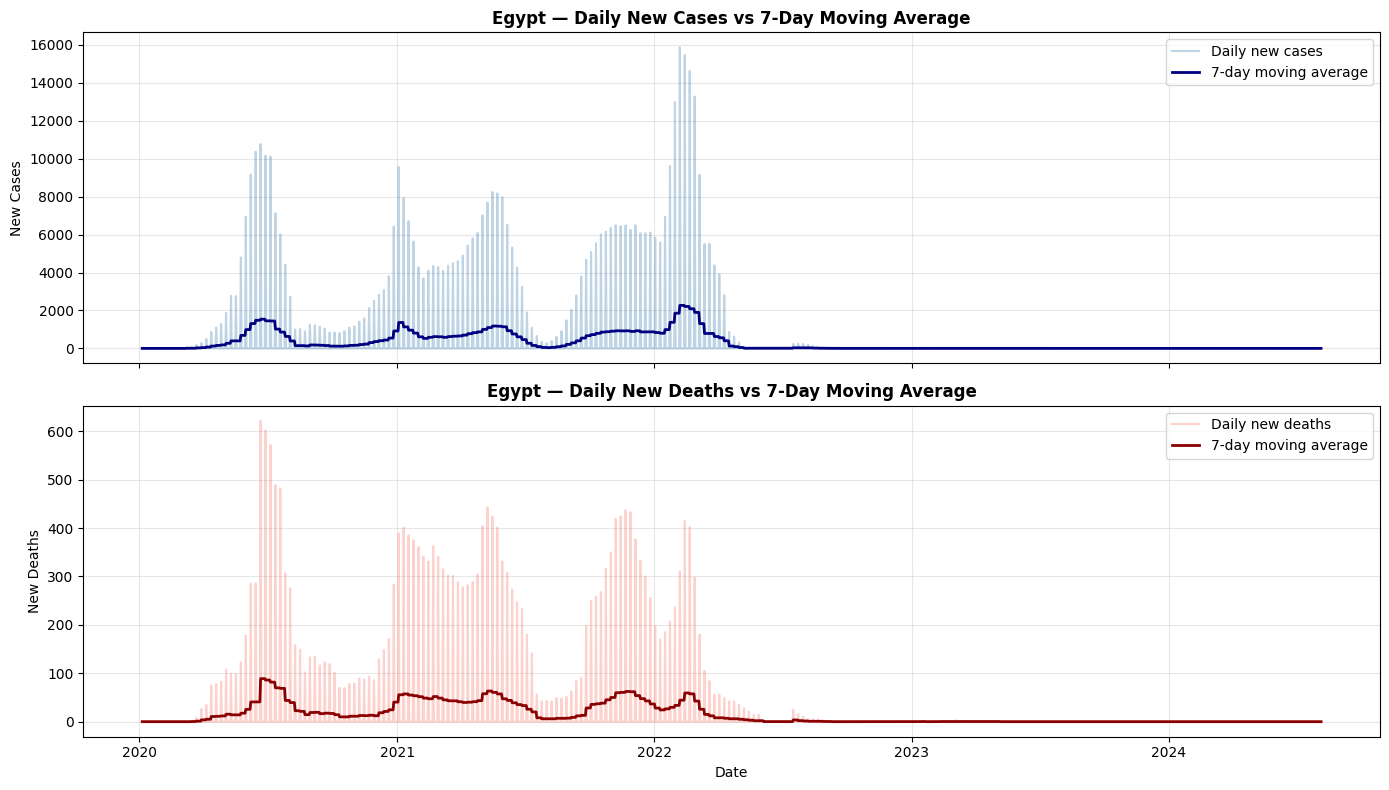

Chart saved -> data/processed/rolling_average_example.png


In [25]:
# 7.3  Visualize raw vs smoothed — example country: Egypt
country_example = 'Egypt'
eg = df[df['location'] == country_example].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cases
axes[0].plot(eg['date'], eg['new_cases'],     alpha=0.35, color='steelblue', label='Daily new cases')
axes[0].plot(eg['date'], eg['cases_7day_ma'], color='navy', linewidth=2,     label='7-day moving average')
axes[0].set_title(f'{country_example} — Daily New Cases vs 7-Day Moving Average', fontweight='bold')
axes[0].set_ylabel('New Cases')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Deaths
axes[1].plot(eg['date'], eg['new_deaths'],      alpha=0.35, color='salmon',  label='Daily new deaths')
axes[1].plot(eg['date'], eg['deaths_7day_ma'],  color='darkred', linewidth=2, label='7-day moving average')
axes[1].set_title(f'{country_example} — Daily New Deaths vs 7-Day Moving Average', fontweight='bold')
axes[1].set_ylabel('New Deaths')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rolling_average_example.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved -> data/processed/rolling_average_example.png")


## 8. Data Aggregation

Three aggregated tables are produced to serve different analytical purposes:

- **Country summary** — one row per country reflecting the latest available observation. Used for cross-country comparisons and choropleth maps.
- **Continent summary** — aggregated continent-level KPIs derived from the country summary. Used for regional comparisons.
- **Global daily summary** — one row per calendar day, aggregated across all countries. Used for global time-series visualizations.

OWID regional aggregates (rows without a valid continent value) are excluded from the global summary to avoid double-counting.


In [26]:
# 8.1  Country-level summary — latest available row per country
country_summary = (
    df.sort_values('date')
      .groupby('location')
      .last()
      .reset_index()
)

country_cols = [
    'location', 'continent', 'date', 'population',
    'total_cases', 'total_deaths', 'total_tests', 'total_vaccinations',
    'people_fully_vaccinated',
    'cases_per_million', 'deaths_per_million',
    'vaccination_rate_pct', 'case_fatality_rate', 'testing_rate',
    'gdp_per_capita', 'median_age', 'aged_65_older',
    'population_density', 'life_expectancy',
    'human_development_index', 'hospital_beds_per_thousand',
    'stringency_index',
]

country_summary = country_summary[[c for c in country_cols if c in country_summary.columns]]

print(f"Country summary: {country_summary.shape[0]} countries x {country_summary.shape[1]} columns")
country_summary.head(3)


Country summary: 237 countries x 22 columns


,location,continent,date,population,total_cases,total_deaths,total_tests,total_vaccinations,people_fully_vaccinated,cases_per_million,deaths_per_million,vaccination_rate_pct,case_fatality_rate,testing_rate,gdp_per_capita,median_age,aged_65_older,population_density,life_expectancy,human_development_index,hospital_beds_per_thousand,stringency_index
0,Afghanistan,Asia,2024-08-04,41128772.00,235214.00,7998.00,994894.00,22964750.00,18370386.00,5718.96,194.46,44.67,3.40,24.19,1803.99,18.60,2.58,54.42,64.83,0.51,0.50,0.00
1,Albania,Europe,2024-08-04,2842318.00,335047.00,3605.00,1613870.00,3088966.00,1279333.00,117878.08,1268.33,45.01,1.08,567.80,11803.43,38.00,13.19,104.87,78.57,0.80,2.89,11.11
2,Algeria,Africa,2024-08-04,44903228.00,272139.00,6881.00,230553.00,15267442.00,6481186.00,6060.57,153.24,14.43,2.53,5.13,13913.84,29.10,6.21,17.35,76.88,0.75,1.90,11.11


In [27]:
# 8.2  Continent-level summary — aggregated from country summary
continent_summary = country_summary.groupby('continent').agg(
    num_countries          = ('location',             'count'),
    total_population       = ('population',           'sum'),
    total_cases            = ('total_cases',          'sum'),
    total_deaths           = ('total_deaths',         'sum'),
    total_vaccinations     = ('total_vaccinations',   'sum'),
    avg_cases_per_million  = ('cases_per_million',    'mean'),
    avg_deaths_per_million = ('deaths_per_million',   'mean'),
    avg_vaccination_rate   = ('vaccination_rate_pct', 'mean'),
    avg_cfr                = ('case_fatality_rate',   'mean'),
    avg_testing_rate       = ('testing_rate',         'mean'),
    avg_gdp_per_capita     = ('gdp_per_capita',       'mean'),
    avg_life_expectancy    = ('life_expectancy',      'mean'),
).reset_index().round(2)

print(f"Continent summary: {continent_summary.shape[0]} continents x {continent_summary.shape[1]} columns")
continent_summary


Continent summary: 6 continents x 13 columns


,continent,num_countries,total_population,total_cases,total_deaths,total_vaccinations,avg_cases_per_million,avg_deaths_per_million,avg_vaccination_rate,avg_cfr,avg_testing_rate,avg_gdp_per_capita,avg_life_expectancy
0,Africa,58,1426736614.00,13145540.00,259118.00,863237900.00,46072.35,311.89,32.96,1.73,135.24,6337.96,65.05
1,Asia,50,4721455390.00,301532347.00,1637249.00,9103443096.00,137884.69,640.18,64.30,1.46,1562.78,23447.34,74.61
2,Europe,50,745629155.00,252642589.00,2099271.00,1397496762.00,407300.46,2672.94,62.28,0.89,4047.89,30640.52,79.31
3,North America,41,600323657.00,124492666.00,1671178.00,1158547416.00,231807.60,1519.81,48.13,1.05,761.10,20899.30,77.29
4,Oceania,24,45038907.00,15003352.00,32918.00,88358812.00,244059.78,557.95,52.66,0.34,471.46,14253.99,73.87
5,South America,14,436816679.00,68809418.00,1355939.00,964991405.00,183750.59,2365.75,61.20,1.79,575.97,13668.20,75.89


In [28]:
# 8.3  Global daily summary — aggregated across all real countries per date
# Rows without a continent value are OWID regional aggregates; excluding them prevents double-counting.
real_countries = df[df['continent'].notna() & (df['continent'] != '')]

global_summary = real_countries.groupby('date').agg(
    total_cases         = ('total_cases',        'sum'),
    total_deaths        = ('total_deaths',       'sum'),
    total_vaccinations  = ('total_vaccinations', 'sum'),
    new_cases           = ('new_cases',          'sum'),
    new_deaths          = ('new_deaths',         'sum'),
    cases_7day_ma       = ('cases_7day_ma',      'sum'),
    deaths_7day_ma      = ('deaths_7day_ma',     'sum'),
    countries_reporting = ('location',           'nunique'),
).reset_index().round(2)

print(f"Global summary: {global_summary.shape[0]} days x {global_summary.shape[1]} columns")
global_summary.tail(5)


Global summary: 1688 days x 9 columns


,date,total_cases,total_deaths,total_vaccinations,new_cases,new_deaths,cases_7day_ma,deaths_7day_ma,countries_reporting
1683,2024-08-10,59731951.00,631575.00,2339746237.00,0.00,0.00,643.71,2.43,7
1684,2024-08-11,59731951.00,631575.00,2318747230.00,0.00,0.00,0.00,0.00,6
1685,2024-08-12,57092903.00,627291.00,2305348848.00,0.00,0.00,0.00,0.00,5
1686,2024-08-13,6678765.00,47161.00,77262138.00,0.00,0.00,0.00,0.00,2
1687,2024-08-14,6678765.00,47161.00,77262153.00,0.00,0.00,0.00,0.00,2


In [29]:
# 8.4  Aggregation validation
print("AGGREGATION VALIDATION")
print("=" * 55)
print(f"  Countries in summary    : {country_summary['location'].nunique()}")
print(f"  Continents covered      : {continent_summary['continent'].tolist()}")
print(f"  Global date range       : {global_summary['date'].min().date()}  ->  {global_summary['date'].max().date()}")
print(f"  Global total cases (M)  : {global_summary['total_cases'].max() / 1e6:.1f}M")
print(f"  Global total deaths (M) : {global_summary['total_deaths'].max() / 1e6:.2f}M")


AGGREGATION VALIDATION
  Countries in summary    : 237
  Continents covered      : ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
  Global date range       : 2020-01-01  ->  2024-08-14
  Global total cases (M)  : 775.6M
  Global total deaths (M) : 7.06M


## 9. Export Final Datasets

Four CSV files are written to the output directory. File sizes are printed as a confirmation that all files were written successfully.


In [30]:
FINAL_PATH     = f'{OUTPUT_DIR}/final_dataset.csv'
COUNTRY_PATH   = f'{OUTPUT_DIR}/country_summary.csv'
CONTINENT_PATH = f'{OUTPUT_DIR}/continent_summary.csv'
GLOBAL_PATH    = f'{OUTPUT_DIR}/global_summary.csv'

df.to_csv(FINAL_PATH,     index=False)
country_summary.to_csv(COUNTRY_PATH,   index=False)
continent_summary.to_csv(CONTINENT_PATH, index=False)
global_summary.to_csv(GLOBAL_PATH,    index=False)

print("All datasets exported successfully:")
print(f"  {FINAL_PATH:<50}  {os.path.getsize(FINAL_PATH)/1e6:.1f} MB")
print(f"  {COUNTRY_PATH:<50}  {os.path.getsize(COUNTRY_PATH)/1024:.0f} KB")
print(f"  {CONTINENT_PATH:<50}  {os.path.getsize(CONTINENT_PATH)/1024:.0f} KB")
print(f"  {GLOBAL_PATH:<50}  {os.path.getsize(GLOBAL_PATH)/1024:.0f} KB")


All datasets exported successfully:
  F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed/final_dataset.csv  154.0 MB
  F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed/country_summary.csv  38 KB
  F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed/continent_summary.csv  1 KB
  F:\faculty\Level 3 S_2\Data Visualization\Global COVID-19 Pandemic Analysis\Global-COVID-19-Pandemic-Analysis\Data\Processed/global_summary.csv  124 KB


In [31]:
# Final column inventory
original_cols   = 70
date_features   = ['year', 'month', 'day', 'date_normalized']
kpi_features    = ['cases_per_million', 'deaths_per_million', 'vaccination_rate_pct',
                   'case_fatality_rate', 'testing_rate']
rolling_features = ['cases_7day_ma', 'deaths_7day_ma']
all_new_cols    = date_features + kpi_features + rolling_features

print("=" * 65)
print("FINAL NOTEBOOK SUMMARY")
print("=" * 65)
print(f"  Input columns (post-cleaning)    : {original_cols}")
print(f"  Dropped (pre-computed KPIs)      : 5  (recalculated below)")
print(f"  Date features added              : {len(date_features)}")
print(f"  KPI features recalculated        : {len(kpi_features)}")
print(f"  Rolling average features added   : {len(rolling_features)}")
print(f"  Net new columns                  : {len(all_new_cols) - 5}")
print(f"  Total columns in final_dataset   : {df.shape[1]}")
print(f"  Total rows                       : {df.shape[0]:,}")
print()
print("  All engineered columns:")
for c in all_new_cols:
    pct = df[c].notnull().mean() * 100
    print(f"    {c:<40}  {pct:.1f}% non-null")
print()
print("  Imputation applied:")
print("    Cumulative columns    ->  Forward fill per country")
print("    Daily new columns     ->  Filled with 0")
print("    Stringency index      ->  Forward fill per country")
print("    tests_units           ->  Filled with 'Unknown'")
print()
print("  Intentionally kept as NaN:")
print("    reproduction_rate, ICU/hospital data (90-94% sparse)")
print("    excess_mortality_* (96.6% sparse)")
print()
print("  Output files:")
print(f"    final_dataset.csv, country_summary.csv,")
print(f"    continent_summary.csv, global_summary.csv")


FINAL NOTEBOOK SUMMARY
  Input columns (post-cleaning)    : 70
  Dropped (pre-computed KPIs)      : 5  (recalculated below)
  Date features added              : 4
  KPI features recalculated        : 5
  Rolling average features added   : 2
  Net new columns                  : 6
  Total columns in final_dataset   : 77
  Total rows                       : 395,311

  All engineered columns:
    year                                      100.0% non-null
    month                                     100.0% non-null
    day                                       100.0% non-null
    date_normalized                           100.0% non-null
    cases_per_million                         100.0% non-null
    deaths_per_million                        100.0% non-null
    vaccination_rate_pct                      100.0% non-null
    case_fatality_rate                        91.7% non-null
    testing_rate                              100.0% non-null
    cases_7day_ma                             100.0